### **1. Identifying Soil Zones**
The statistical characteristics of the four clusters are analyzed here. By looking at the mean values of original soil properties (pH, Organic Carbon, Sand %, etc.), meaningful names can be assigned to these zones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_final = pd.read_csv("../outputs/soil_clusters.csv")

cluster_summary = df_final.groupby("cluster")[[
    "taw", "organic_carbon", "cec", "ph", "sand_pct"
]].mean().round(2)

print("Mean Soil Properties per Cluster:")
print(cluster_summary)

Mean Soil Properties per Cluster:
          taw  organic_carbon    cec    ph  sand_pct
cluster                                             
0        8.83            2.91  16.64  5.19     70.33
1        6.90            3.18   9.77  4.86     66.24
2        6.63            3.31  17.20  5.34     78.85
3        7.79            4.11  18.65  4.81     62.29


### **2. Visualizing the Differences**

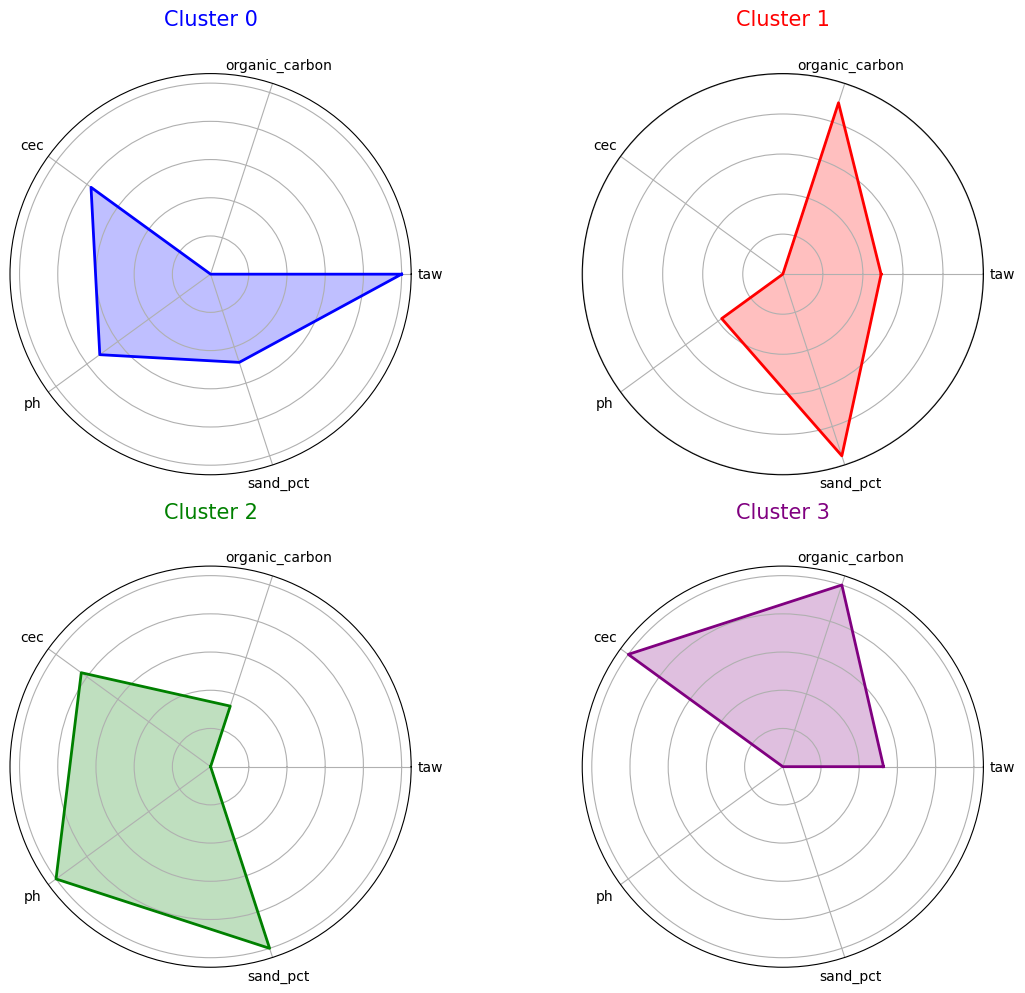

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Normalize the data for the radar chart (0 to 1 scale for visualization)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cluster_norm = pd.DataFrame(scaler.fit_transform(cluster_summary), 
                            columns=cluster_summary.columns, 
                            index=cluster_summary.index)

def make_radar_chart(df, cluster_id, color):
    labels = df.columns
    num_vars = len(labels)
    
    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    
    values = df.loc[cluster_id].tolist()
    values += values[:1]
    
    ax = plt.subplot(2, 2, cluster_id + 1, polar=True)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.plot(angles, values, color=color, linewidth=2)
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(f"Cluster {cluster_id}", size=15, color=color, y=1.1)

plt.figure(figsize=(12, 10))
colors = ['blue', 'red', 'green', 'purple']
for i in range(4):
    make_radar_chart(cluster_norm, i, colors[i])

plt.tight_layout()
plt.show()

#### **Cluster 0 – Moisture buffering sandy loam**
Strong extension on TAW, moderate on CEC and pH, mid‑high on sand_pct, and low on organic_carbon were shown in the chart.

This zone is a coarse to medium textured soil with the highest available water capacity, meaning it can buffer short dry spells better than the others despite being sandy. Chemically it is moderate. CEC is decent but organic carbon is relatively low, so nutrient storage is acceptable but not exceptional. Acidity is moderate (pH around the middle of the group), so most crops can grow with standard fertilization and, where needed, modest liming.

#### **Cluster 1 – Nutrient poor, strongly acidic sand**
Chart pulled toward the centre on CEC and TAW, with low pH and high sand_pct, but slightly higher organic_carbon than Cluster 0.

This zone is the most leached and chemically weak. It has the lowest nutrient holding capacity (CEC) and low water holding (TAW) on a sandy, and strongly acidic soil. Even though organic carbon is moderate, the low CEC and low pH mean nutrients are easily lost and many crops will struggle. Agronomically, this is a high risk zone that requires significant amendments like liming to raise pH, plus sustained organic matter and fertilizer inputs before intensifying to high value cropping.

#### **Cluster 2 – Very sandy, drought prone but chemically moderate**
Chart showed strong spike on sand_pct, moderate‑high on CEC and organic_carbon, lowest on TAW, and highest pH among the clusters (though still slightly acidic overall).

This is the most physically drought prone soil. It is very sandy with the lowest available water, so it dries quickly but also drains well, reducing risk of waterlogging and root rot. In contrast to Cluster 1, its CEC and organic carbon are reasonably good, and its pH is the least acidic of all clusters. This makes it a well drained but nutrient capable sandy soil. This is good for crops that dislike wet feet, provided irrigation or mulching is used to manage rapid drying.

#### **Cluster 3 – High fertility, fine textured but acidic**
Longest arms on organic_carbon and CEC, relatively high TAW, lowest sand_pct, and low pH were shown in the chart.

This is the chemically strongest and finest textured zone. It has the highest organic matter and CEC mean excellent capacity to store nutrients and buffer fertilizer applications. Lower sand_pct implies more silt/clay, which together with high organic carbon that supports good water holding. However, pH is still clearly acidic. In practice, this is a high potential production zone. Once acidity is corrected with lime, it can support demanding, high yield crops. Without liming, it suits acid tolerant species too.

### **3. Spatial Distribution of Soil Clusters in the Western Province**

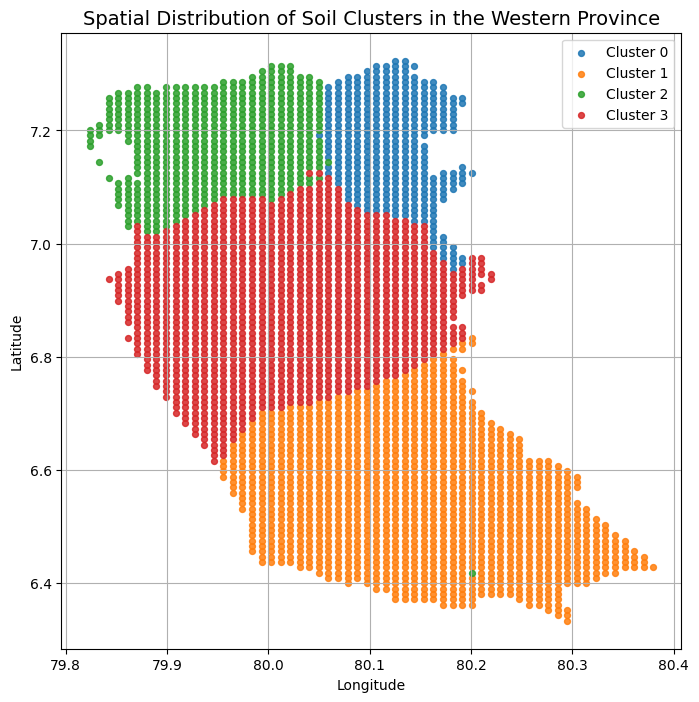

In [6]:
plt.figure(figsize=(8, 8))

for c in sorted(df_final["cluster"].unique()):
    subset = df_final[df_final["cluster"] == c]
    plt.scatter(
        subset["lon"],
        subset["lat"],
        s=18,
        label=f"Cluster {c}",
        alpha=0.85
    )

plt.title("Spatial Distribution of Soil Clusters in the Western Province", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()
